In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/Cleaned_Dataset_IntermodalRail.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 257
Columns: 19


In [3]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numeric Columns:")
print(numeric_columns)

Numeric Columns:
['temperature_celsius', 'humidity_percentage', 'vibration_level', 'pressure_kpa', 'exposure_duration_hours', 'door_open_count', 'salinity_ppt', 'thermal_leakage_score', 'spoilage_risk_percent', 'remaining_shelf_life_days']


In [4]:
df[numeric_columns].head()

,temperature_celsius,humidity_percentage,vibration_level,pressure_kpa,exposure_duration_hours,door_open_count,salinity_ppt,thermal_leakage_score,spoilage_risk_percent,remaining_shelf_life_days
0,3.8,62.4,1.8,0.0,159.2,0,0.0,4.5,20.3,4.0
1,4.5,47.4,4.3,0.0,143.1,0,0.0,4.3,13.5,4.7
2,3.1,35.8,0.4,0.0,141.9,0,0.0,3.2,18.7,5.2
3,7.2,50.7,2.6,0.0,153.1,0,0.0,1.4,8.3,28.2
4,11.5,34.1,3.0,0.0,140.2,0,0.0,3.4,8.8,11.0


In [6]:
corr = df[numeric_columns].corr()

print("Correlation Matrix:")
display(corr)

Correlation Matrix:


,temperature_celsius,humidity_percentage,vibration_level,pressure_kpa,exposure_duration_hours,door_open_count,salinity_ppt,thermal_leakage_score,spoilage_risk_percent,remaining_shelf_life_days
temperature_celsius,1.000000,-0.015315,0.061364,NaN,-0.090161,NaN,NaN,0.011093,0.067000,0.225224
humidity_percentage,-0.015315,1.000000,0.018237,NaN,-0.041870,NaN,NaN,-0.045424,0.373197,-0.041623
vibration_level,0.061364,0.018237,1.000000,NaN,-0.065534,NaN,NaN,-0.073182,-0.068152,0.053054
pressure_kpa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exposure_duration_hours,-0.090161,-0.041870,-0.065534,NaN,1.000000,NaN,NaN,-0.040266,0.132253,0.072140
door_open_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salinity_ppt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thermal_leakage_score,0.011093,-0.045424,-0.073182,NaN,-0.040266,NaN,NaN,1.000000,0.421821,-0.129018
spoilage_risk_percent,0.067000,0.373197,-0.068152,NaN,0.132253,NaN,NaN,0.421821,1.000000,-0.268796
remaining_shelf_life_days,0.225224,-0.041623,0.053054,NaN,0.072140,NaN,NaN,-0.129018,-0.268796,1.000000


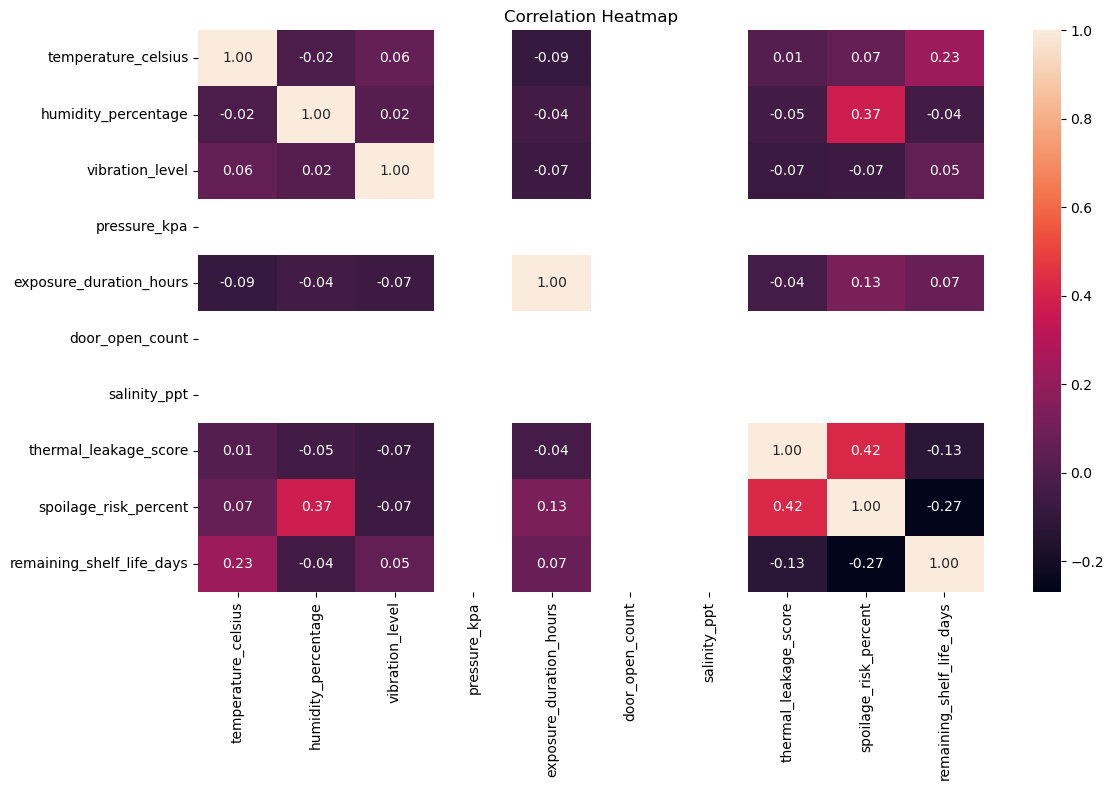

In [7]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [8]:
risk_correlations = corr[
    "spoilage_risk_percent"
].sort_values(
    ascending=False
)

print("Correlation with Spoilage Risk:")
print(risk_correlations)

Correlation with Spoilage Risk:
spoilage_risk_percent        1.000000
thermal_leakage_score        0.421821
humidity_percentage          0.373197
exposure_duration_hours      0.132253
temperature_celsius          0.067000
vibration_level             -0.068152
remaining_shelf_life_days   -0.268796
pressure_kpa                      NaN
door_open_count                   NaN
salinity_ppt                      NaN
Name: spoilage_risk_percent, dtype: float64
